In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P9 - Simpson's paradox during ramp-up

## 1. What goes wrong
A test ramps up at 10% treatment during a high-conversion sale, then runs at 50%. Pooling all days compares a mostly-sale control with a mostly-normal treatment.

## 2. Simulate

In [2]:
from abtest.pitfalls import simpson
sp = simpson.simpson_study(n_sims=80)
sp

{'true_effect': 0.0,
 'pooled_avg_effect': -0.010965678073876694,
 'stratified_avg_effect': 0.00017801422513895256,
 'pooled_false_positive_rate': np.float64(1.0)}

## 3. Quantify the damage

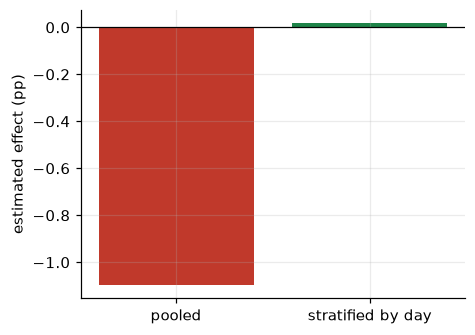

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 3.4)); ax.bar(['pooled', 'stratified by day'], [sp['pooled_avg_effect'] * 100, sp['stratified_avg_effect'] * 100], color=[BAD, GOOD]); ax.axhline(0, color='k', lw=.8); ax.set(ylabel='estimated effect (pp)'); plt.show()

## 4. Detect

Plot the treatment share by day. If it changed during the test, pooled results are suspect.

## 5. Fix

Stratify by day (weighted average of daily differences), or analyse only the period after the ramp finished.

## 6. Verify the fix

_The fix is procedural; see the Detect section for how it is checked._

## So what
When allocation changes while the baseline also changes, pooled results can show a large effect that does not exist. Stratifying by day removes the bias.